Bank Marketing Dataset Classification

Objective: Predict whether a customer subscribes to a term deposit

1. Problem Statement and Objective

Problem:
We aim to predict whether a bank customer will subscribe to a term deposit using historical marketing campaign data.

Objective:

Understand the dataset
Preprocess and clean the data
Perform exploratory data analysis (EDA)
Build machine learning models (Logistic Regression, Random Forest)
Evaluate models using F1 Score and ROC-AUC
Identify important features and explain predictions using LIME

2. Dataset Description and Loading

In [21]:
import pandas as pd

file_name = "bank-full.csv"  # Update filename if needed

# Load with semicolon separator (UCI dataset uses ;)
data = pd.read_csv(file_name, sep=";")

# If loaded incorrectly, try comma separator
if data.shape[1] == 1:
    data = pd.read_csv(file_name, sep=",")

# Preview data
data.head()
# Dataset shape
data.shape
# Dataset info and columns
data.info()
data.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 2.0 MB


['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'deposit']

3. Target Column and Distribution

In [22]:
# Identify target column
target_column = "y" if "y" in data.columns else "deposit"

# Display target distribution
data[target_column].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

4. Data Cleaning and Preprocessing

In [23]:
# Strip column spaces
data.columns = data.columns.str.strip()

# Remove duplicates
data = data.drop_duplicates()

# Fill missing values
for col in data.columns:
    if col == target_column:
        continue
    if pd.api.types.is_numeric_dtype(data[col]):
        data[col] = data[col].fillna(data[col].median())
    else:
        data[col] = data[col].fillna(data[col].mode()[0])

# Check missing values
data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

5. Features and Target Separation

In [24]:
X = data.drop(columns=[target_column])
y = data[target_column].map({"yes": 1, "no": 0})  # Encode target

X.head(), y.head()

(   age         job  marital  education default  balance housing loan  contact  \
 0   59      admin.  married  secondary      no     2343     yes   no  unknown   
 1   56      admin.  married  secondary      no       45      no   no  unknown   
 2   41  technician  married  secondary      no     1270     yes   no  unknown   
 3   55    services  married  secondary      no     2476     yes   no  unknown   
 4   54      admin.  married   tertiary      no      184      no   no  unknown   
 
    day month  duration  campaign  pdays  previous poutcome  
 0    5   may      1042         1     -1         0  unknown  
 1    5   may      1467         1     -1         0  unknown  
 2    5   may      1389         1     -1         0  unknown  
 3    5   may       579         1     -1         0  unknown  
 4    5   may       673         2     -1         0  unknown  ,
 0    1
 1    1
 2    1
 3    1
 4    1
 Name: deposit, dtype: int64)

6. Encode Categorical Features

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert to numpy arrays to avoid feature name warnings
X_values = X_encoded.values
y_values = y.values

X_train, X_test, y_train, y_test = train_test_split(
    X_values,
    y_values,
    test_size=0.2,
    random_state=42,
    stratify=y_values
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (8929, 42)
Testing data shape: (2233, 42)


7. Train-Test Split

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

8. Scaling for Logistic Regression

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

9. Logistic Regression Model

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

10. Random Forest Model

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight="balanced"
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

11. Model Evaluation


==== Logistic Regression ====

Confusion Matrix:
 [[986 189]
 [194 864]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84      1175
           1       0.82      0.82      0.82      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233

F1 Score: 0.8186
ROC-AUC Score: 0.9072


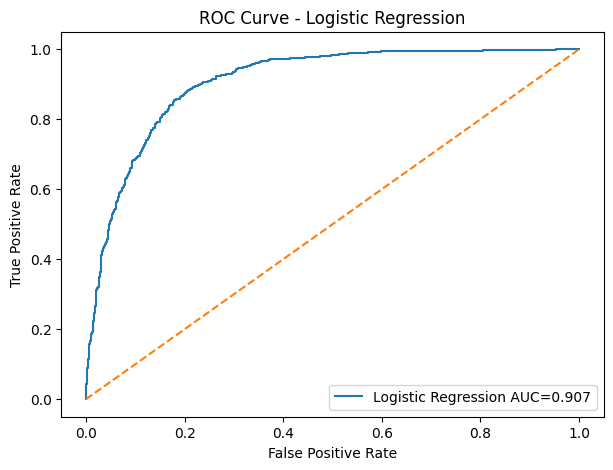


==== Random Forest ====

Confusion Matrix:
 [[978 197]
 [120 938]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86      1175
           1       0.83      0.89      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233

F1 Score: 0.8554
ROC-AUC Score: 0.9205


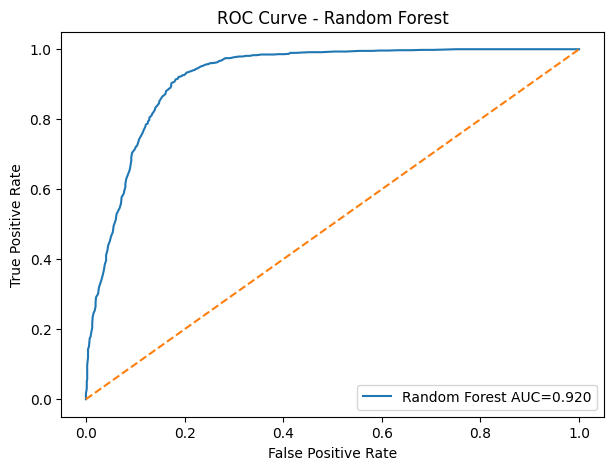

In [37]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"\n==== {model_name} ====")
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    print("F1 Score:", round(f1,4))
    print("ROC-AUC Score:", round(auc,4))
    
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f"{model_name} AUC={auc:.3f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()
    
    return f1, auc

log_f1, log_auc = evaluate_model("Logistic Regression", y_test, log_pred, log_prob)
rf_f1, rf_auc = evaluate_model("Random Forest", y_test, rf_pred, rf_prob)

12. Model Comparison

In [38]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "F1 Score": [log_f1, rf_f1],
    "ROC-AUC": [log_auc, rf_auc]
})

comparison

,Model,F1 Score,ROC-AUC
0,Logistic Regression,0.818569,0.907204
1,Random Forest,0.855449,0.920476


13. Feature Importance - Random Forest

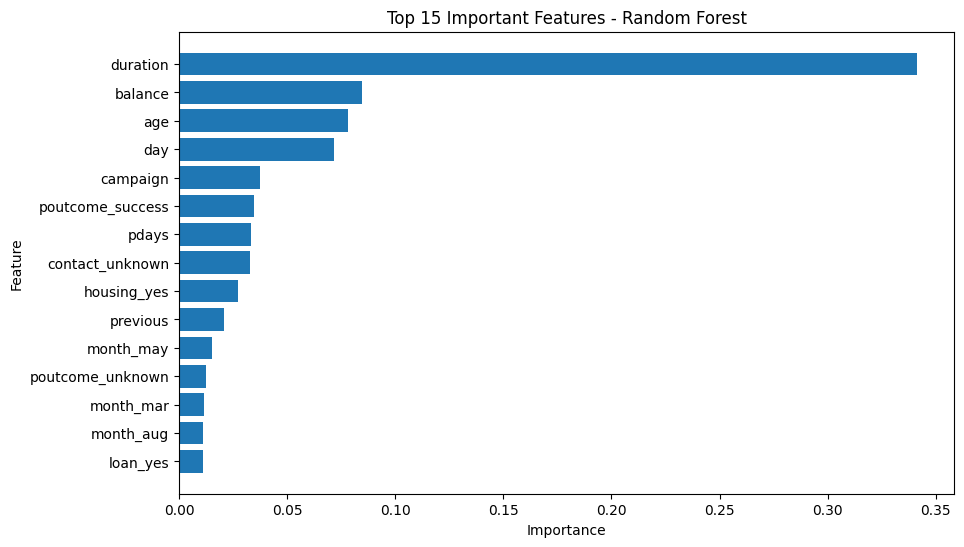

In [39]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)
plt.figure(figsize=(10,6))
plt.barh(feature_importance.head(15)["Feature"], feature_importance.head(15)["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features - Random Forest")
plt.show()

14. LIME Explanations

In [51]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Keep feature names
feature_names = X_encoded.columns.tolist()

# LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_train,           # numpy array
    feature_names=feature_names,     # column names
    class_names=["No", "Yes"],
    mode="classification"
)

# Explain first 5 predictions
for i in range(5):
    # Use 1D numpy array
    data_row = X_test[i]

    exp = explainer.explain_instance(
        data_row=data_row,
        predict_fn=rf_model.predict_proba,
        num_features=10
    )

    print(f"\nCustomer {i+1} Prediction Explanation")
    print("Actual Value:", y_test[i])
    print("Predicted Probability of Subscription:", rf_prob[i])

    for feature, value in exp.as_list():
        print(feature, ":", value)

    exp.save_to_file(f"lime_explanation_customer_{i+1}.html")

print("\nLIME explanations saved for 5 test customers.")


Customer 1 Prediction Explanation
Actual Value: 0
Predicted Probability of Subscription: 0.645
month_mar <= 0.00 : -0.15609515203687538
poutcome_success <= 0.00 : -0.13569735386507706
month_oct <= 0.00 : -0.10742968696531027
month_sep <= 0.00 : -0.08461757610814419
contact_unknown <= 0.00 : 0.07897339816272539
253.00 < duration <= 492.00 : 0.05966739043991929
job_self-employed <= 0.00 : 0.05438144202913651
housing_yes <= 0.00 : 0.05413345527997187
month_jul <= 0.00 : 0.05032075830047529
month_may <= 0.00 : 0.047476313566315397

Customer 2 Prediction Explanation
Actual Value: 1
Predicted Probability of Subscription: 0.72
month_mar <= 0.00 : -0.17328022322220937
poutcome_success <= 0.00 : -0.1479950828588757
month_oct <= 0.00 : -0.10125538411090058
contact_unknown <= 0.00 : 0.07932814610849452
month_jun <= 0.00 : -0.06494398301299846
month_sep <= 0.00 : -0.06078717216530761
253.00 < duration <= 492.00 : 0.05475219505940067
housing_yes <= 0.00 : 0.05180096174697829
month_may <= 0.00 : 0.

15. Save Results

In [52]:
comparison.to_csv("model_comparison.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)
print("Files saved: model_comparison.csv, feature_importance.csv, lime_explanation_customer_1-5.html")

Files saved: model_comparison.csv, feature_importance.csv, lime_explanation_customer_1-5.html
